# 03 — Benford por órgão (16 meses, 2023–abr/2024)

96.413 licitações consolidadas. Teste de Benford segmentado por órgão superior,
com métrica MAD (Nigrini) para comparação independente de tamanho de amostra.

## Achados
- **χ²/p-valor enganam com amostra grande:** Defesa e Educação tinham χ² altíssimo
  apenas pelo volume (36k, 23k linhas). MAD reordenou o ranking corretamente.
- **Qualidade de dado:** 12,6% dos registros são placeholders (valor 0/0,01/1,00).
  O valor R$ 1,00 é vício quase exclusivo do MJSP (615 de 631 casos) — convenção
  de sistema distinta dos demais órgãos (que usam 0).
- **MJSP (maior desvio, MAD 0,033 pós-limpeza):** desvio persiste após limpeza.
  Causa provável NÃO é fraude, mas compras padronizadas replicadas (valores
  múltiplos de um unitário de R$ 822,88). Recomendação: análise de sobrepreço
  unitário, não de fatiamento.
- **Cultura (MAD 0,032):** desvio "limpo", sem causa identificada — próximo alvo.

## Lição metodológica
Benford é peneira de anomalias, não detector de fraude. Anomalia pode ser: dado
sujo, padrão legítimo ou fraude. Distinguir os três é o trabalho de auditoria.

In [2]:
import sys
sys.path.append("..")

from src.carga import carregar_licitacoes

df = carregar_licitacoes("../data/raw")
print(df.shape)
df["arquivo_origem"].value_counts().sort_index()

(96413, 18)


arquivo_origem
202301_Licitação.csv    3678
202302_Licitação.csv    4985
202303_Licitação.csv    9971
202304_Licitação.csv    5997
202305_Licitação.csv    7292
202306_Licitação.csv    7039
202307_Licitação.csv    6984
202308_Licitação.csv    7885
202309_Licitação.csv    7183
202310_Licitação.csv    7900
202311_Licitação.csv    9883
202312_Licitação.csv    9552
202401_Licitação.csv    2537
202402_Licitação.csv    2153
202403_Licitação.csv    2653
202404_Licitação.csv     721
Name: count, dtype: int64

In [3]:
df = carregar_licitacoes("../data/raw")
print(df.shape)
df["arquivo_origem"].value_counts().sort_index()

(96413, 18)


arquivo_origem
202301_Licitação.csv    3678
202302_Licitação.csv    4985
202303_Licitação.csv    9971
202304_Licitação.csv    5997
202305_Licitação.csv    7292
202306_Licitação.csv    7039
202307_Licitação.csv    6984
202308_Licitação.csv    7885
202309_Licitação.csv    7183
202310_Licitação.csv    7900
202311_Licitação.csv    9883
202312_Licitação.csv    9552
202401_Licitação.csv    2537
202402_Licitação.csv    2153
202403_Licitação.csv    2653
202404_Licitação.csv     721
Name: count, dtype: int64

In [4]:
df = carregar_licitacoes("../data/raw")
print(df.shape)
df["arquivo_origem"].value_counts().sort_index()

(96413, 18)


arquivo_origem
202301_Licitação.csv    3678
202302_Licitação.csv    4985
202303_Licitação.csv    9971
202304_Licitação.csv    5997
202305_Licitação.csv    7292
202306_Licitação.csv    7039
202307_Licitação.csv    6984
202308_Licitação.csv    7885
202309_Licitação.csv    7183
202310_Licitação.csv    7900
202311_Licitação.csv    9883
202312_Licitação.csv    9552
202401_Licitação.csv    2537
202402_Licitação.csv    2153
202403_Licitação.csv    2653
202404_Licitação.csv     721
Name: count, dtype: int64

In [5]:
df = carregar_licitacoes("../data/raw")
print(df.shape)
df["arquivo_origem"].value_counts().sort_index()

(96413, 18)


arquivo_origem
202301_Licitação.csv    3678
202302_Licitação.csv    4985
202303_Licitação.csv    9971
202304_Licitação.csv    5997
202305_Licitação.csv    7292
202306_Licitação.csv    7039
202307_Licitação.csv    6984
202308_Licitação.csv    7885
202309_Licitação.csv    7183
202310_Licitação.csv    7900
202311_Licitação.csv    9883
202312_Licitação.csv    9552
202401_Licitação.csv    2537
202402_Licitação.csv    2153
202403_Licitação.csv    2653
202404_Licitação.csv     721
Name: count, dtype: int64

In [6]:
# Quantas licitacoes por orgao superior, e valor mediano de cada
resumo = df.groupby("Nome Órgão Superior").agg(
    qtd=("Valor Licitação", "size"),
    valor_mediano=("Valor Licitação", "median"),
).sort_values("qtd", ascending=False)

resumo.head(15)

,qtd,valor_mediano
Nome Órgão Superior,,
Ministério da Defesa,40175,3000.000
Ministério da Educação,28324,6240.000
Ministério da Saúde,5573,20945.520
Ministério da Justiça e Segurança Pública,2848,2083.100
Ministério da Agricultura e Pecuária,2776,7960.000
"Ministério da Ciência, Tecnologia e Inovaç",2505,5556.590
Ministério de Minas e Energia,1830,16408.640
Ministério da Fazenda,1428,19915.000
Ministério dos Transportes,1406,46787.500


In [7]:
from src.benford import benford_por_grupo

ranking = benford_por_grupo(df, "Valor Licitação", "Nome Órgão Superior")
ranking

,Nome Órgão Superior,n,chi2,p_valor,mad
0,Ministério da Justiça e Segurança Pública,2694,840.349031,4.128276e-176,0.058255
1,Ministério da Cultura,1268,320.222588,2.031541e-64,0.032022
2,Ministério das Relações Exteriores,301,20.935627,7.320410e-03,0.024814
3,Ministério do Meio Ambiente e Mudança do Cl,513,19.151588,1.406964e-02,0.020462
4,Ministério dos Povos Indígenas,621,22.829655,3.589974e-03,0.019717
5,Ministério do Desenvolvimento Agrário e Agr,870,24.148452,2.164038e-03,0.015959
6,Ministério da Gestão e da Inovação em Ser,1294,22.587868,3.935702e-03,0.013700
7,"Ministério da Ciência, Tecnologia e Inovaç",2437,33.381399,5.256585e-05,0.011272
8,Ministério dos Transportes,1333,19.225454,1.369932e-02,0.010043
9,Ministério do Planejamento e Orçamento,666,7.591540,4.743506e-01,0.009706


In [8]:
from src.benford import benford_por_grupo

ranking = benford_por_grupo(df, "Valor Licitação", "Nome Órgão Superior")
ranking

,Nome Órgão Superior,n,chi2,p_valor,mad
0,Ministério da Justiça e Segurança Pública,2694,840.349031,4.128276e-176,0.058255
1,Ministério da Cultura,1268,320.222588,2.031541e-64,0.032022
2,Ministério das Relações Exteriores,301,20.935627,7.320410e-03,0.024814
3,Ministério do Meio Ambiente e Mudança do Cl,513,19.151588,1.406964e-02,0.020462
4,Ministério dos Povos Indígenas,621,22.829655,3.589974e-03,0.019717
5,Ministério do Desenvolvimento Agrário e Agr,870,24.148452,2.164038e-03,0.015959
6,Ministério da Gestão e da Inovação em Ser,1294,22.587868,3.935702e-03,0.013700
7,"Ministério da Ciência, Tecnologia e Inovaç",2437,33.381399,5.256585e-05,0.011272
8,Ministério dos Transportes,1333,19.225454,1.369932e-02,0.010043
9,Ministério do Planejamento e Orçamento,666,7.591540,4.743506e-01,0.009706


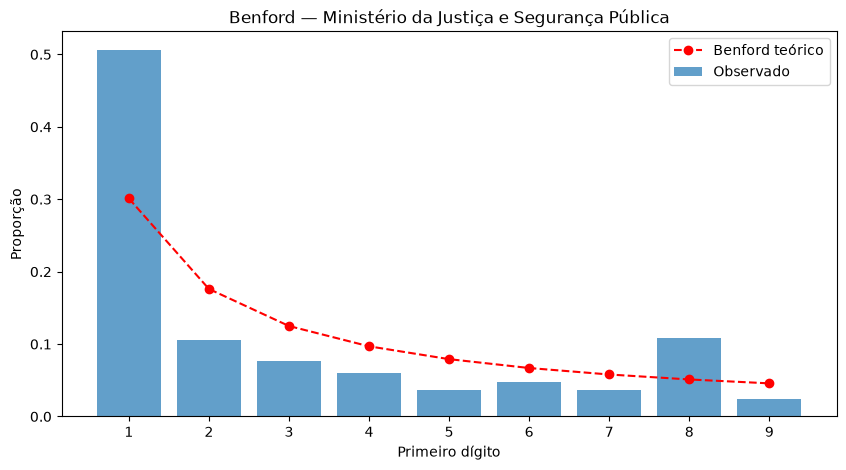

,esperado,observado,desvio
1,0.301030,0.506310,0.205280
2,0.176091,0.105048,-0.071043
3,0.124939,0.076095,-0.048844
4,0.096910,0.059762,-0.037148
5,0.079181,0.036377,-0.042804
6,0.066947,0.047142,-0.019805
7,0.057992,0.037120,-0.020872
8,0.051153,0.108018,0.056865
9,0.045757,0.024128,-0.021630


In [9]:
from src.benford import plotar_grupo

tabela_justica = plotar_grupo(
    df, "Valor Licitação", "Nome Órgão Superior",
    "Ministério da Justiça e Segurança Pública",
    salvar="../reports/benford_justica.png"
)
tabela_justica

In [10]:
justica = df[df["Nome Órgão Superior"] == "Ministério da Justiça e Segurança Pública"]
justica = justica[justica["Valor Licitação"] > 0]

# Os 15 valores que mais se repetem nesse ministerio
justica["Valor Licitação"].value_counts().head(15)

Valor Licitação
1.00        615
822.88      218
1645.76     191
1234.32      71
17600.00     57
2468.64      48
3291.52      28
4114.40      22
3932.40      16
6554.00      11
2006.76      10
2675.68       7
7208.00       7
1201.36       7
4013.52       7
Name: count, dtype: int64

In [11]:
# Quantas licitacoes tem valores "suspeitos de placeholder" no dataset inteiro?
placeholders = df[df["Valor Licitação"].isin([0, 1, 0.01])]
print(f"Total de placeholders (0, 0.01, 1.00): {len(placeholders)}")
print(f"Proporcao: {len(placeholders) / len(df):.1%}")

# So o valor 1.00, por orgao
df[df["Valor Licitação"] == 1.00]["Nome Órgão Superior"].value_counts().head(10)

Total de placeholders (0, 0.01, 1.00): 12151
Proporcao: 12.6%


Nome Órgão Superior
Ministério da Justiça e Segurança Pública    615
Ministério da Defesa                           9
Ministério da Educação                         6
Ministério dos Transportes                     1
Name: count, dtype: int64

In [12]:
from src.limpeza import limpar_valores

df_limpo = limpar_valores(df)

# Reroda o ranking nos dados limpos
ranking_limpo = benford_por_grupo(df_limpo, "Valor Licitação", "Nome Órgão Superior")
ranking_limpo

Removidos 12151 registros placeholder (12.6% do total)
Restaram 84262 licitacoes com valor economico real


,Nome Órgão Superior,n,chi2,p_valor,mad
0,Ministério da Justiça e Segurança Pública,2074,423.545394,1.713608e-86,0.032634
1,Ministério da Cultura,1268,320.222588,2.031541e-64,0.032022
2,Ministério das Relações Exteriores,301,20.935627,7.320410e-03,0.024814
3,Ministério do Meio Ambiente e Mudança do Cl,512,18.861704,1.561701e-02,0.020275
4,Ministério dos Povos Indígenas,621,22.829655,3.589974e-03,0.019717
5,Ministério do Desenvolvimento Agrário e Agr,869,24.032855,2.262900e-03,0.015848
6,Ministério da Gestão e da Inovação em Ser,1293,22.332401,4.335919e-03,0.013623
7,"Ministério da Ciência, Tecnologia e Inovaç",2435,32.952119,6.282376e-05,0.011190
8,Ministério dos Transportes,1328,19.973741,1.043585e-02,0.010462
9,Ministério da Agricultura e Pecuária,2571,37.338519,9.970669e-06,0.009880


In [13]:
%pip install pyarrow


Note: you may need to restart the kernel to use updated packages.


In [14]:
df_limpo.to_parquet("../data/processed/licitacoes_limpo.parquet")
print("Salvo:", df_limpo.shape)


Salvo: (84262, 18)
